In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import joblib
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [6]:
# Load the dataset
data = pd.read_csv("C:\\Users\\germa\\Downloads\\RF_Project\\data\\processed\\RF_test_train.csv")  
v_data = pd.read_csv("C:\\Users\\germa\\Downloads\\RF_Project\\data\\processed\\RF_validation.csv")
# Split features and target
X = data[["x_mean","y_mean","z_mean","x_std","y_std","z_std","x_sum","y_sum","z_sum","x_median","y_median","z_median"]]
y = data["Label"]  # Replace 'label' with your actual target column name

v_X = v_data[["x_mean","y_mean","z_mean","x_std","y_std","z_std","x_sum","y_sum","z_sum","x_median","y_median","z_median"]]  
v_y = v_data["Label"]  # Replace 'label' with your actual target column name

print(X.head()) # Inspect the features
print(y.head())  # Inspect the target

      x_mean       y_mean    z_mean        x_std        y_std        z_std  \
0  -0.196629  -996.473034  3.642697  1745.398533  1164.439618  1380.794059   
1 -13.230337  -998.838202  3.874157  1797.108902  1213.156222  1405.578406   
2  -4.147191 -1005.369663 -5.728090  1693.027882  1329.661392  1417.965701   
3  -5.660674  -994.339326  1.720225  1714.892402  1234.185835  1373.864111   
4   2.253933 -1004.379775  0.122472  1826.890824  1248.814379  1581.981154   

     x_sum     y_sum   z_sum  x_median  y_median  z_median  
0   -175.0 -886861.0  3242.0      22.0   -1056.5      55.0  
1 -11775.0 -888966.0  3448.0      58.0   -1080.0     129.0  
2  -3691.0 -894779.0 -5098.0       9.0   -1100.0      69.0  
3  -5038.0 -884962.0  1531.0      21.0   -1038.0      79.5  
4   2006.0 -893898.0   109.0      18.0   -1021.0     101.0  
0    1
1    1
2    1
3    1
4    1
Name: Label, dtype: int64


In [7]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

Training data shape: (4321, 12)
Test data shape: (1081, 12)


In [11]:
# Scaling the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)
v_X = scaler.fit_transform(v_X)

In [13]:
# Creating an instance of SVC and train the model
random_forest_model = RandomForestClassifier(random_state=42) 
random_forest_model.fit(X_train, y_train)

# Function to calculate the total number of nodes and the maximum depth in the forest
def calculate_nodes_and_max_depth(model):
    total_nodes = 0
    max_depth = 0
    # Loop over each decision tree in the random forest
    for tree in model.estimators_:
        total_nodes += tree.tree_.node_count  # Count nodes in the tree
        max_depth = max(max_depth, tree.tree_.max_depth)  # Update max depth if necessary
    return total_nodes, max_depth

# Call the function to get the total number of nodes and the maximum depth
total_nodes, max_depth = calculate_nodes_and_max_depth(random_forest_model)

# Output the results
print(f"Total number of nodes in the random forest: {total_nodes}")
print(f"Maximum depth of the trees in the random forest: {max_depth}")
#tree = DecisionTreeClassifier()
#print(f'Decision tree has {random_forest_model.tree_.node_count} nodes with maximum depth {random_forest_model.tree_.max_depth}.')

Total number of nodes in the random forest: 50924
Maximum depth of the trees in the random forest: 26


In [15]:
# Computing the predictions on X_train and X_test
y_pred_train = random_forest_model.predict(X_train)
y_pred_prob_train = random_forest_model.predict_proba(X_train)[:, 1]
y_pred_test = random_forest_model.predict(X_test)
y_pred_prob_test = random_forest_model.predict_proba(X_test)[:, 1]

Validation Test Accuracy: 0.6842543737850597

Validation Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.39      0.55      1800
           1       0.62      0.98      0.76      1801

    accuracy                           0.68      3601
   macro avg       0.78      0.68      0.65      3601
weighted avg       0.78      0.68      0.65      3601


Validation Confussion Matrix: 


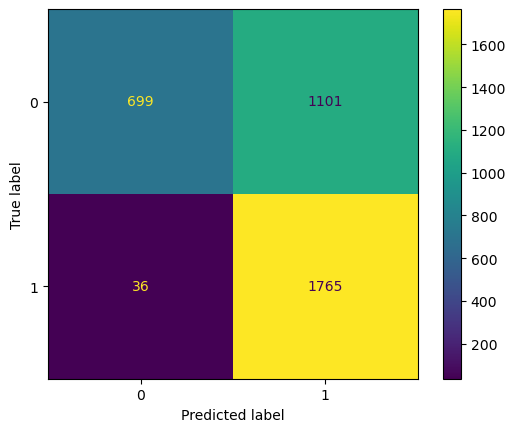

In [31]:
y_pred_val = random_forest_model.predict(v_X)


# Printing out the results
print("Validation Test Accuracy:", accuracy_score(v_y, y_pred_val))
print("\nValidation Classification Report:\n", classification_report(v_y, y_pred_val))
print("\nValidation Confussion Matrix: \n", ConfusionMatrixDisplay.from_predictions(v_y, y_pred_val))



Accuracy on Train Data:  1.0
Accuracy on Test Data:  0.9195189639222942

Classification Report (Train Data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1449
           1       1.00      1.00      1.00      2872

    accuracy                           1.00      4321
   macro avg       1.00      1.00      1.00      4321
weighted avg       1.00      1.00      1.00      4321


Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.91      0.83      0.87       351
           1       0.92      0.96      0.94       730

    accuracy                           0.92      1081
   macro avg       0.92      0.90      0.91      1081
weighted avg       0.92      0.92      0.92      1081


ROC AUC (Train Data):  1.0
ROC AUC (Test Data):  0.9804335948171564


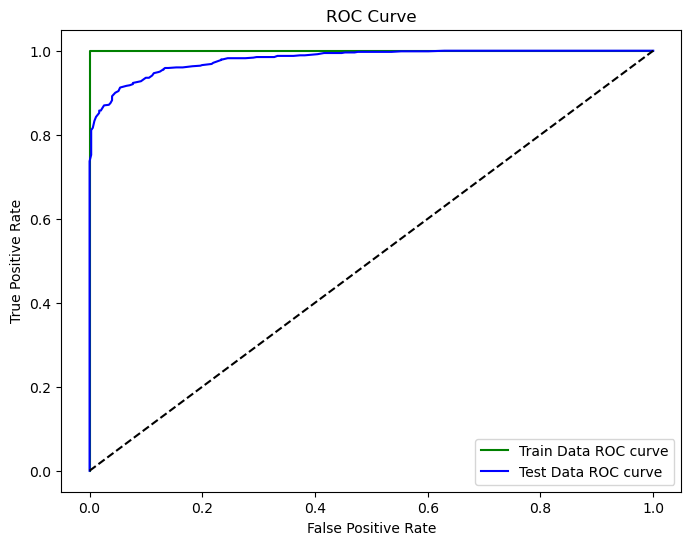

In [167]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

def evaluate_model(y_pred_train, y_pred_prob_train, y_pred_test, y_pred_prob_test, y_train, y_test):
    # Accuracy on test and train data
    print("Accuracy on Train Data: ", accuracy_score(y_train, y_pred_train))
    print("Accuracy on Test Data: ", accuracy_score(y_test, y_pred_test))
    
    # Classification report on test and train data
    print("\nClassification Report (Train Data):")
    print(classification_report(y_train, y_pred_train))
    
    print("\nClassification Report (Test Data):")
    print(classification_report(y_test, y_pred_test))
    
    # ROC AUC on test and train data
    print("\nROC AUC (Train Data): ", roc_auc_score(y_train, y_pred_prob_train))
    print("ROC AUC (Test Data): ", roc_auc_score(y_test, y_pred_prob_test))
    
    # Plot ROC curve
    fpr_train, tpr_train, _ = roc_curve(y_train, y_pred_prob_train)
    fpr_test, tpr_test, _ = roc_curve(y_test, y_pred_prob_test)
    
    plt.figure(figsize=(8,6))
    plt.plot(fpr_train, tpr_train, color='green', label='Train Data ROC curve')
    plt.plot(fpr_test, tpr_test, color='blue', label='Test Data ROC curve')
    plt.plot([0, 1], [0, 1], color='black', linestyle='--')  # Diagonal line representing random classifier
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

# Now call the function using the predicted values and true labels:
evaluate_model(y_pred_train, y_pred_prob_train, y_pred_test, y_pred_prob_test, y_train, y_test)


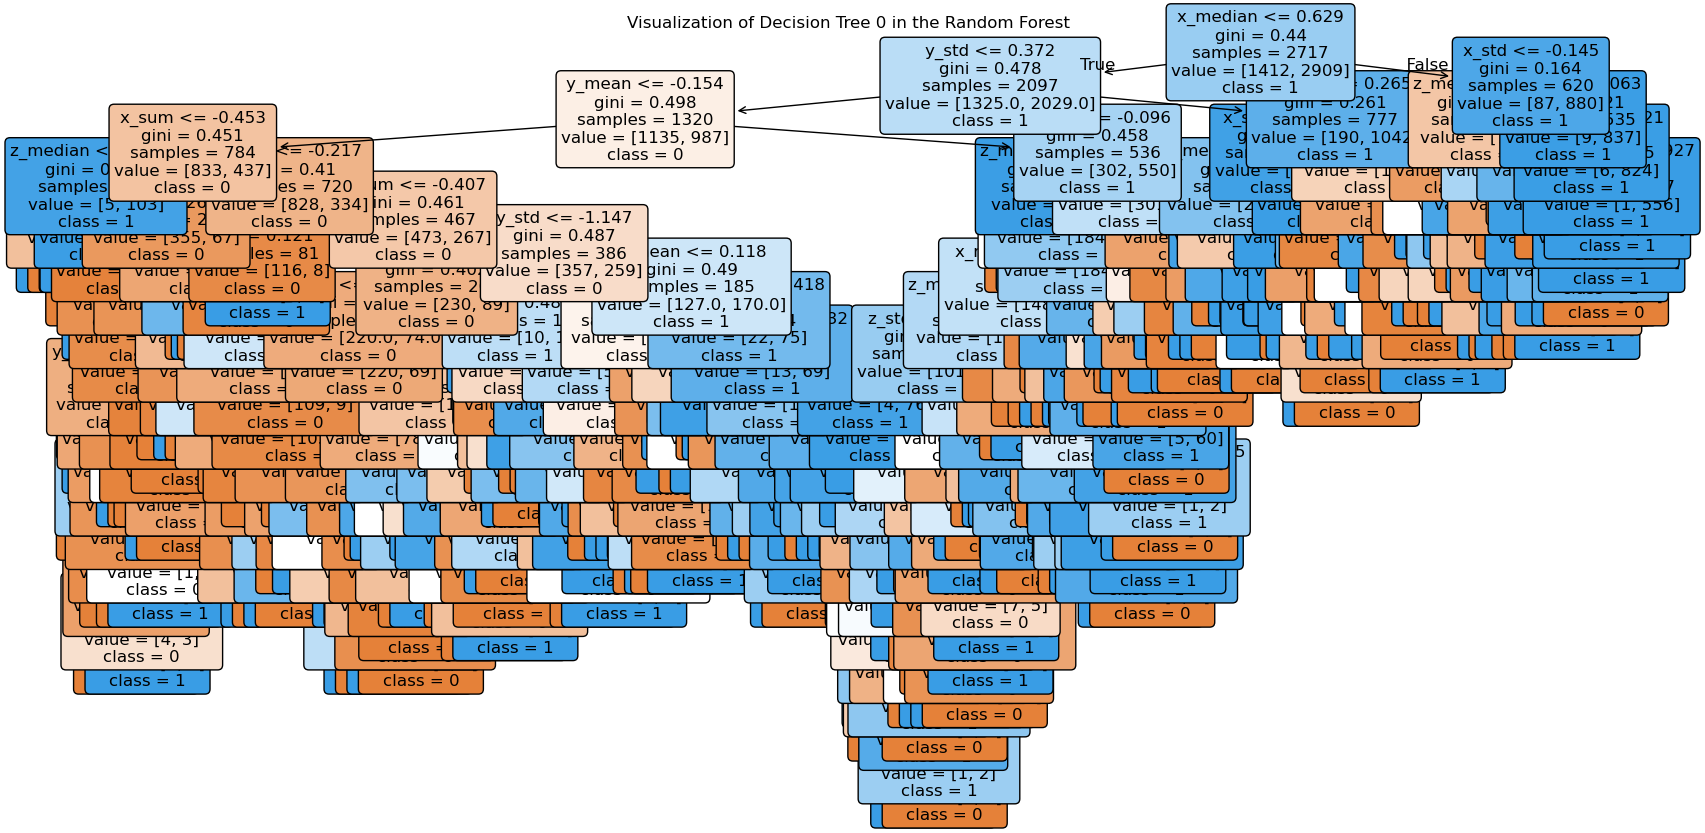

In [207]:
# Function to plot a tree from the Random Forest model
def plot_random_forest_tree(model, tree_index=0, figsize=(20, 10)):
    # Get the individual tree from the Random Forest model
    tree = model.estimators_[tree_index]
    
    # Plot the selected tree
    plt.figure(figsize=figsize)
    plot_tree(tree, filled=True, feature_names=X.columns, class_names=['0', '1'], rounded=True, fontsize=12)
    plt.title(f"Visualization of Decision Tree {tree_index} in the Random Forest")
    plt.show()



for i in range(1):
    plot_random_forest_tree(random_forest_model, tree_index=i)

In [33]:
# Save the pipeline
joblib.dump(random_forest_model, "tool_classification_pipeline.pkl")

['tool_classification_pipeline.pkl']